In [1]:
!pip install -q transformers
!pip install -q timm
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.7 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

In [4]:
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")

model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model loaded on:", device)

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda


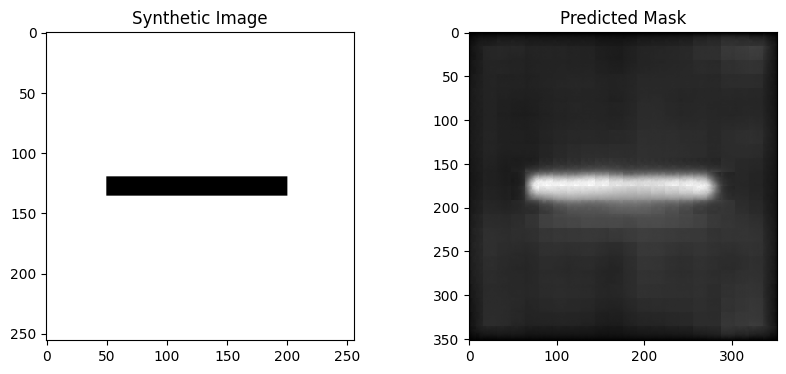

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Create a simple synthetic image (white background with a black line)
img_array = np.ones((256, 256, 3), dtype=np.uint8) * 255
img_array[120:136, 50:200] = 0  # draw a black line (like a crack)

image = Image.fromarray(img_array)

prompt = "segment crack"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

pred_mask = torch.sigmoid(outputs.logits)[0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Synthetic Image")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")

plt.show()

In [6]:
!ls /kaggle/input/datasets/krishnasaigollamudi/cracks

README.dataset.txt  README.roboflow.txt  test  train  valid


In [7]:
!ls /kaggle/input/datasets/krishnasaigollamudi/drywall

README.dataset.txt  README.roboflow.txt  train	valid


In [8]:
!find /kaggle/input/datasets/krishnasaigollamudi/cracks -name "*.json"

/kaggle/input/datasets/krishnasaigollamudi/cracks/valid/_annotations.coco.json
/kaggle/input/datasets/krishnasaigollamudi/cracks/test/_annotations.coco.json
/kaggle/input/datasets/krishnasaigollamudi/cracks/train/_annotations.coco.json


In [9]:
!pip install pycocotools

In [10]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

def generate_masks(split_path, prompt, save_dir):

    ann_file = os.path.join(split_path, "_annotations.coco.json")
    coco = COCO(ann_file)

    os.makedirs(save_dir, exist_ok=True)

    for img_id in coco.imgs:

        img_info = coco.imgs[img_id]
        height = img_info["height"]
        width = img_info["width"]

        mask = np.zeros((height, width), dtype=np.uint8)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:

            # CASE 1: segmentation polygons exist
            if "segmentation" in ann and len(ann["segmentation"]) > 0:
                try:
                    m = coco.annToMask(ann)
                    mask = np.maximum(mask, m)
                except:
                    pass

            # CASE 2: only bounding box exists
            elif "bbox" in ann:
                x, y, w, h = ann["bbox"]
                x, y, w, h = map(int, [x, y, w, h])
                mask[y:y+h, x:x+w] = 1

        mask = mask * 255

        name = img_info["file_name"].split(".")[0]
        mask_name = f"{name}__{prompt.replace(' ','_')}.png"

        Image.fromarray(mask).save(os.path.join(save_dir, mask_name))

In [11]:
!rm -rf /kaggle/working/crack_train_masks
!rm -rf /kaggle/working/drywall_train_masks

In [12]:
generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/cracks/train",
    "segment crack",
    "/kaggle/working/crack_train_masks"
)

generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/drywall/train",
    "segment drywall seam",
    "/kaggle/working/drywall_train_masks"
)

loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [13]:
import os

print("Crack masks:", len(os.listdir("/kaggle/working/crack_train_masks")))
print("Drywall masks:", len(os.listdir("/kaggle/working/drywall_train_masks")))

Crack masks: 898
Drywall masks: 160


In [14]:
from pycocotools.coco import COCO

ann_file = "/kaggle/input/datasets/krishnasaigollamudi/cracks/train/_annotations.coco.json"
coco = COCO(ann_file)

print("Images in annotation file:", len(coco.imgs))
print("Annotations:", len(coco.anns))

loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Images in annotation file: 4027
Annotations: 6341


In [15]:
!rm -rf /kaggle/working/crack_train_masks
!rm -rf /kaggle/working/drywall_train_masks

In [16]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

def generate_masks(split_path, prompt, save_dir):

    ann_file = os.path.join(split_path, "_annotations.coco.json")
    coco = COCO(ann_file)

    os.makedirs(save_dir, exist_ok=True)

    total = len(coco.imgs)
    count = 0

    for img_id, img_info in coco.imgs.items():

        height = img_info["height"]
        width = img_info["width"]

        mask = np.zeros((height, width), dtype=np.uint8)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:

            if "segmentation" in ann and len(ann["segmentation"]) > 0:
                try:
                    m = coco.annToMask(ann)
                    mask = np.maximum(mask, m)
                except:
                    pass

            elif "bbox" in ann:
                x, y, w, h = ann["bbox"]
                x, y, w, h = map(int, [x, y, w, h])
                mask[y:y+h, x:x+w] = 1

        mask = mask * 255

        # IMPORTANT: use img_id to avoid overwriting
        mask_name = f"{img_id}__{prompt.replace(' ','_')}.png"

        Image.fromarray(mask).save(os.path.join(save_dir, mask_name))

        count += 1
        if count % 500 == 0:
            print(f"{count}/{total} masks generated")

    print("Finished generating", count, "masks")

In [17]:
generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/cracks/train",
    "segment crack",
    "/kaggle/working/crack_train_masks"
)

loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
500/4027 masks generated
1000/4027 masks generated
1500/4027 masks generated
2000/4027 masks generated
2500/4027 masks generated
3000/4027 masks generated
3500/4027 masks generated
4000/4027 masks generated
Finished generating 4027 masks


In [18]:
import os
print("Crack masks:", len(os.listdir("/kaggle/working/crack_train_masks")))

Crack masks: 4027


In [19]:
generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/drywall/train",
    "segment drywall seam",
    "/kaggle/working/drywall_train_masks"
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
500/820 masks generated
Finished generating 820 masks


In [20]:
import os

print("Crack masks:", len(os.listdir("/kaggle/working/crack_train_masks")))
print("Drywall masks:", len(os.listdir("/kaggle/working/drywall_train_masks")))

Crack masks: 4027
Drywall masks: 820


In [21]:
!pip install transformers accelerate

In [22]:
import torch
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

In [23]:
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [26]:
import torch
from torch.utils.data import DataLoader, ConcatDataset

crack_dataset = SegmentationDataset(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/cracks/train",
    mask_dir="/kaggle/working/crack_train_masks",
    prompts=["segment crack", "segment wall crack"],
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/cracks/train/_annotations.coco.json"
)

drywall_dataset = SegmentationDataset(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/drywall/train",
    mask_dir="/kaggle/working/drywall_train_masks",
    prompts=["segment taping area", "segment joint/tape", "segment drywall seam"],
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/drywall/train/_annotations.coco.json"
)

dataset = ConcatDataset([crack_dataset, drywall_dataset])
print(f"Total dataset size: {len(dataset)}")

def collate_fn(batch):
    keys = batch[0].keys()
    collated = {}
    for k in keys:
        if k in ('input_ids', 'attention_mask'):
            max_len = max(b[k].shape[0] for b in batch)
            padded = []
            for b in batch:
                t = b[k]
                pad_val = processor.tokenizer.pad_token_id if k == 'input_ids' else 0
                padded.append(torch.cat([t, torch.full((max_len - t.shape[0],), pad_val, dtype=t.dtype)]))
            collated[k] = torch.stack(padded)
        else:
            collated[k] = torch.stack([b[k] for b in batch])
    return collated

loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Total dataset size: 4847


In [25]:
import os
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from torchvision import transforms
import torch

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, prompts, coco_ann_file, size=(352,352)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.prompts = prompts
        self.files = os.listdir(mask_dir)
        self.size = size
        coco = COCO(coco_ann_file)
        self.id_to_file = {str(img_id): info['file_name'] for img_id, info in coco.imgs.items()}

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mask_file = self.files[idx]
        image_id = mask_file.split("__")[0]
        image_file = self.id_to_file[image_id]
        image = Image.open(os.path.join(self.image_dir, image_file)).convert("RGB").resize(self.size)
        mask = Image.open(os.path.join(self.mask_dir, mask_file)).convert("L").resize(self.size, Image.NEAREST)

        if random.random() > 0.5:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)
        if random.random() > 0.5:
            image = transforms.functional.vflip(image)
            mask = transforms.functional.vflip(mask)
        angle = random.uniform(-15, 15)
        image = transforms.functional.rotate(image, angle)
        mask = transforms.functional.rotate(mask, angle)

        image = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(image)

        prompt = random.choice(self.prompts)
        inputs = processor(text=prompt, images=image, return_tensors="pt",
                           padding="max_length", max_length=77, truncation=True, do_resize=True)
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(np.array(mask)).float() / 255.0
        return inputs

In [27]:
import os
import time
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from pycocotools.coco import COCO
from torchvision import transforms
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import CLIPSegForImageSegmentation, CLIPSegProcessor

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").to(device)
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred).view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

def combined_loss(logits, labels):
    bce = torch.nn.BCEWithLogitsLoss()(logits, labels)
    dl = dice_loss(logits, labels)
    return 0.5 * bce + 0.5 * dl

def dice_coef(pred, target, eps=1e-6):
    pred, target = pred.view(-1), target.view(-1)
    return (2*(pred*target).sum() + eps) / (pred.sum() + target.sum() + eps)

def iou_score(pred, target, eps=1e-6):
    pred, target = pred.view(-1), target.view(-1)
    intersection = (pred*target).sum()
    return (intersection + eps) / (pred.sum() + target.sum() - intersection + eps)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
threshold = 0.5
train_start = time.time()

def run_epochs(num_epochs, stage="S1"):
    for epoch in range(num_epochs):
        model.train()
        total_loss = total_dice = total_iou = 0.0
        progress = tqdm(loader, desc=f"{stage} Epoch {epoch+1}/{num_epochs}", leave=True)
        for i, batch in enumerate(progress, 1):
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            h, w = logits.shape[-2], logits.shape[-1]
            labels_resized = F.interpolate(labels.unsqueeze(1), size=(h, w), mode='nearest').squeeze(1)
            loss = combined_loss(logits, labels_resized)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                pred_mask = (torch.sigmoid(logits) > threshold).float()
                total_loss += loss.item()
                total_dice += dice_coef(pred_mask, labels_resized)
                total_iou += iou_score(pred_mask, labels_resized)
            progress.set_postfix({
                "Loss": f"{total_loss/i:.4f}",
                "Dice": f"{total_dice/i:.4f}",
                "IoU":  f"{total_iou/i:.4f}"
            })
        n = len(loader)
        print(f"{stage} Epoch {epoch+1}/{num_epochs} Loss: {total_loss/n:.4f} Dice: {total_dice/n:.4f} IoU: {total_iou/n:.4f}")
        model.save_pretrained(f"/kaggle/working/{stage}_ckpt_ep{epoch+1}")
        processor.save_pretrained(f"/kaggle/working/{stage}_ckpt_ep{epoch+1}")
        print(f"✓ Saved {stage}_ckpt_ep{epoch+1}")

print("\n=== Stage 1: lr=1e-5, 10 epochs ===")
run_epochs(10, stage="S1")

print("\n=== Stage 2: lr=5e-6, 10 epochs ===")
for pg in optimizer.param_groups:
    pg['lr'] = 5e-6
run_epochs(10, stage="S2")

total_time = (time.time() - train_start) / 60
print(f"\n✓ Total training time: {total_time:.1f} minutes")
model.save_pretrained("/kaggle/working/clipseg_final")
processor.save_pretrained("/kaggle/working/clipseg_final")
print("✓ Final model saved")

Device: cuda


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Stage 1: lr=1e-5, 10 epochs ===


S1 Epoch 1/10: 100%|██████████| 1212/1212 [05:42<00:00,  3.54it/s, Loss=0.4097, Dice=0.4218, IoU=0.2807]

...

S2 Epoch 10/10 Loss: 0.2714 Dice: 0.6225 IoU: 0.4587


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Saved S2_ckpt_ep10

✓ Total training time: 108.5 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Final model saved


In [28]:
print(os.listdir("/kaggle/input/datasets/krishnasaigollamudi/cracks"))

['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']


In [30]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from transformers import CLIPSegForImageSegmentation, CLIPSegProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPSegForImageSegmentation.from_pretrained("/kaggle/working/clipseg_final").to(device)
processor = CLIPSegProcessor.from_pretrained("/kaggle/working/clipseg_final")
model.eval()

def run_inference(image_dir, output_dir, prompt, threshold=0.5):
    os.makedirs(output_dir, exist_ok=True)
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    times = []
    
    for image_file in tqdm(image_files, desc=f"Running: {prompt}"):
        image_id = os.path.splitext(image_file)[0]
        orig_image = Image.open(os.path.join(image_dir, image_file)).convert("RGB")
        orig_w, orig_h = orig_image.size
        
        inputs = processor(text=prompt, images=orig_image, return_tensors="pt",
                           padding="max_length", max_length=77, truncation=True).to(device)
        
        import time
        start = time.time()
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits  # (1, H, W)
        times.append(time.time() - start)
        
        # resize to original image size
        pred = torch.sigmoid(logits[0])
        pred_resized = torch.nn.functional.interpolate(
            pred.unsqueeze(0).unsqueeze(0), size=(orig_h, orig_w), mode='bilinear', align_corners=False
        ).squeeze()
        
        mask = (pred_resized > threshold).cpu().numpy().astype(np.uint8) * 255
        
        # filename format: imageid__prompt.png
        prompt_slug = prompt.replace(" ", "_")
        out_filename = f"{image_id}__{prompt_slug}.png"
        Image.fromarray(mask).save(os.path.join(output_dir, out_filename))
    
    print(f"Avg inference time: {np.mean(times)*1000:.1f}ms/image")
    return times

# run on both test sets
run_inference(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/cracks/test",
    output_dir="/kaggle/working/predictions",
    prompt="segment crack"
)

run_inference(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/drywall/valid",
    output_dir="/kaggle/working/predictions",
    prompt="segment taping area"
)

# model size
total_params = sum(p.numel() for p in model.parameters())
print(f"Model size: {total_params/1e6:.1f}M parameters")

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

Running: segment crack: 100%|██████████| 268/268 [00:21<00:00, 12.66it/s]


Avg inference time: 39.8ms/image


Running: segment taping area: 100%|██████████| 202/202 [00:15<00:00, 12.96it/s]

Avg inference time: 41.9ms/image
Model size: 150.7M parameters


In [31]:
generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/cracks/test",
    "segment crack",
    "/kaggle/working/crack_test_masks"
)

generate_masks(
    "/kaggle/input/datasets/krishnasaigollamudi/drywall/valid",
    "segment taping area",
    "/kaggle/working/drywall_valid_masks"
)


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Finished generating 268 masks
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Finished generating 202 masks


In [32]:
def evaluate(image_dir, mask_dir, pred_dir, prompt, coco_ann_file):
    coco = COCO(coco_ann_file)
    # map filename -> coco id
    file_to_id = {info['file_name']: str(img_id) for img_id, info in coco.imgs.items()}
    
    total_dice = total_iou = 0.0
    count = 0
    prompt_slug = prompt.replace(" ", "_")
    
    for mask_file in tqdm(os.listdir(mask_dir)):
        coco_id = mask_file.split("__")[0]
        
        # find the original filename for this coco_id
        id_to_file = {str(img_id): info['file_name'] for img_id, info in coco.imgs.items()}
        if coco_id not in id_to_file:
            continue
        orig_filename = id_to_file[coco_id]
        # build pred filename using orig filename without extension
        orig_stem = os.path.splitext(orig_filename)[0]
        pred_file = f"{orig_stem}__{prompt_slug}.png"
        pred_path = os.path.join(pred_dir, pred_file)
        if not os.path.exists(pred_path):
            continue
        
        gt = np.array(Image.open(os.path.join(mask_dir, mask_file)).convert("L")).astype(np.float32) / 255.0
        pred = np.array(Image.open(pred_path).convert("L")).astype(np.float32) / 255.0
        
        if gt.shape != pred.shape:
            pred = np.array(Image.fromarray((pred*255).astype(np.uint8)).resize(
                (gt.shape[1], gt.shape[0]), Image.NEAREST)).astype(np.float32) / 255.0
        
        intersection = (pred * gt).sum()
        dice = (2 * intersection + 1e-6) / (pred.sum() + gt.sum() + 1e-6)
        iou = (intersection + 1e-6) / (pred.sum() + gt.sum() - intersection + 1e-6)
        total_dice += dice
        total_iou += iou
        count += 1
    
    print(f"\n[{prompt}]")
    print(f"  Dice:  {total_dice/count:.4f}")
    print(f"  IoU:   {total_iou/count:.4f}")
    print(f"  Count: {count}")
    return total_dice/count, total_iou/count

In [33]:
evaluate(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/cracks/test",
    mask_dir="/kaggle/working/crack_test_masks",
    pred_dir="/kaggle/working/predictions",
    prompt="segment crack",
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/cracks/test/_annotations.coco.json"
)

evaluate(
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/drywall/valid",
    mask_dir="/kaggle/working/drywall_valid_masks",
    pred_dir="/kaggle/working/predictions",
    prompt="segment taping area",
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/drywall/valid/_annotations.coco.json"
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


100%|██████████| 268/268 [00:00<00:00, 272.46it/s]



[segment crack]
  Dice:  0.5503
  IoU:   0.4051
  Count: 268
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


100%|██████████| 202/202 [00:00<00:00, 272.78it/s]


[segment taping area]
  Dice:  0.6128
  IoU:   0.4581
  Count: 202


(np.float32(0.61283535), np.float32(0.4580557))

In [34]:
from PIL import Image
import os

# check one crack prediction
pred_file = os.listdir("/kaggle/working/predictions")[0]
pred = Image.open(f"/kaggle/working/predictions/{pred_file}")
print("Pred size:", pred.size)
print("Pred mode:", pred.mode)

# check corresponding source image
print("Pred filename:", pred_file)

Pred size: (640, 640)
Pred mode: L
Pred filename: IMG_8222_JPG_jpg.rf.30ff365f7d71f6749639d7c4bf3421e3__segment_taping_area.png


In [35]:
# check source image size
crack_images = os.listdir("/kaggle/input/datasets/krishnasaigollamudi/cracks/test")
crack_images = [f for f in crack_images if f.endswith(('.jpg', '.jpeg', '.png'))]
src = Image.open(f"/kaggle/input/datasets/krishnasaigollamudi/cracks/test/{crack_images[0]}")
print("Source size:", src.size)
print("Source file:", crack_images[0])

Source size: (640, 640)
Source file: brick_cracking57_jpg.rf.1b2451a8b53d5be5000de2893380875c.jpg


In [36]:
import os
preds = os.listdir("/kaggle/working/predictions")
print("Current prediction filenames:")
for f in preds[:5]:
    print(f)

Current prediction filenames:
IMG_8222_JPG_jpg.rf.30ff365f7d71f6749639d7c4bf3421e3__segment_taping_area.png
a_16_0_png_jpg.rf.c932f5bad05368406bd5c8bfbb05ab83__segment_crack.png
cracking0102240_jpg.rf.b614b173556934cace476562cbe7d5ba__segment_crack.png
brick_cracking57_jpg.rf.1b2451a8b53d5be5000de2893380875c__segment_crack.png
IMG_8216_JPG_jpg.rf.069e0b925a406c76fd6d1d4db2e2f7c5__segment_taping_area.png


In [37]:
from pycocotools.coco import COCO
import os

def rename_predictions(pred_dir, coco_ann_file, image_dir, prompt):
    coco = COCO(coco_ann_file)
    # map original filename stem -> coco id
    stem_to_id = {
        os.path.splitext(info['file_name'])[0]: str(img_id) 
        for img_id, info in coco.imgs.items()
    }
    prompt_slug = prompt.replace(" ", "_")
    renamed = 0
    for fname in os.listdir(pred_dir):
        if prompt_slug not in fname:
            continue
        stem = fname.replace(f"__{prompt_slug}.png", "")
        if stem in stem_to_id:
            coco_id = stem_to_id[stem]
            new_name = f"{coco_id}__{prompt_slug}.png"
            os.rename(
                os.path.join(pred_dir, fname),
                os.path.join(pred_dir, new_name)
            )
            renamed += 1
    print(f"Renamed {renamed} files for prompt: {prompt}")

rename_predictions(
    pred_dir="/kaggle/working/predictions",
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/cracks/test/_annotations.coco.json",
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/cracks/test",
    prompt="segment crack"
)

rename_predictions(
    pred_dir="/kaggle/working/predictions",
    coco_ann_file="/kaggle/input/datasets/krishnasaigollamudi/drywall/valid/_annotations.coco.json",
    image_dir="/kaggle/input/datasets/krishnasaigollamudi/drywall/valid",
    prompt="segment taping area"
)

# verify
preds = os.listdir("/kaggle/working/predictions")
print("\nSample renamed filenames:")
for f in preds[:5]:
    print(f)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Renamed 268 files for prompt: segment crack
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Renamed 202 files for prompt: segment taping area

Sample renamed filenames:
3__segment_taping_area.png
251__segment_crack.png
138__segment_taping_area.png
193__segment_taping_area.png
147__segment_taping_area.png


In [38]:
print("Crack train:", len(os.listdir("/kaggle/working/crack_train_masks")))
print("Drywall train:", len(os.listdir("/kaggle/working/drywall_train_masks")))
print("Crack test:", len(os.listdir("/kaggle/working/crack_test_masks")))
print("Drywall val:", len(os.listdir("/kaggle/working/drywall_valid_masks")))

Crack train: 4027
Drywall train: 820
Crack test: 268
Drywall val: 202


In [41]:
# check what's in predictions
preds = os.listdir("/kaggle/working/predictions")
print("Sample predictions:", preds[:3])

# check mask files
masks = os.listdir("/kaggle/working/crack_test_masks")
print("Sample masks:", masks[:3])

# check if they match
coco = COCO("/kaggle/input/datasets/krishnasaigollamudi/cracks/test/_annotations.coco.json")
id_to_file = {str(img_id): info['file_name'] for img_id, info in coco.imgs.items()}

mask_file = masks[0]
coco_id = mask_file.split("__")[0]
orig_filename = id_to_file.get(coco_id, "NOT FOUND")
orig_stem = os.path.splitext(orig_filename)[0]
pred_file = f"{orig_stem}__segment_crack.png"
print(f"\nMask: {mask_file}")
print(f"Looking for pred: {pred_file}")
print(f"Exists: {os.path.exists('/kaggle/working/predictions/' + pred_file)}")

Sample predictions: ['3__segment_taping_area.png', '251__segment_crack.png', '138__segment_taping_area.png']
Sample masks: ['251__segment_crack.png', '40__segment_crack.png', '154__segment_crack.png']
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!

Mask: 251__segment_crack.png
Looking for pred: 865-dat_png_jpg.rf.59bff3d0abbb9dd475b85f8d10666280__segment_crack.png
Exists: False


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
✓ Saved /kaggle/working/visuals_crack.png
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✓ Saved /kaggle/working/visuals_drywall.png


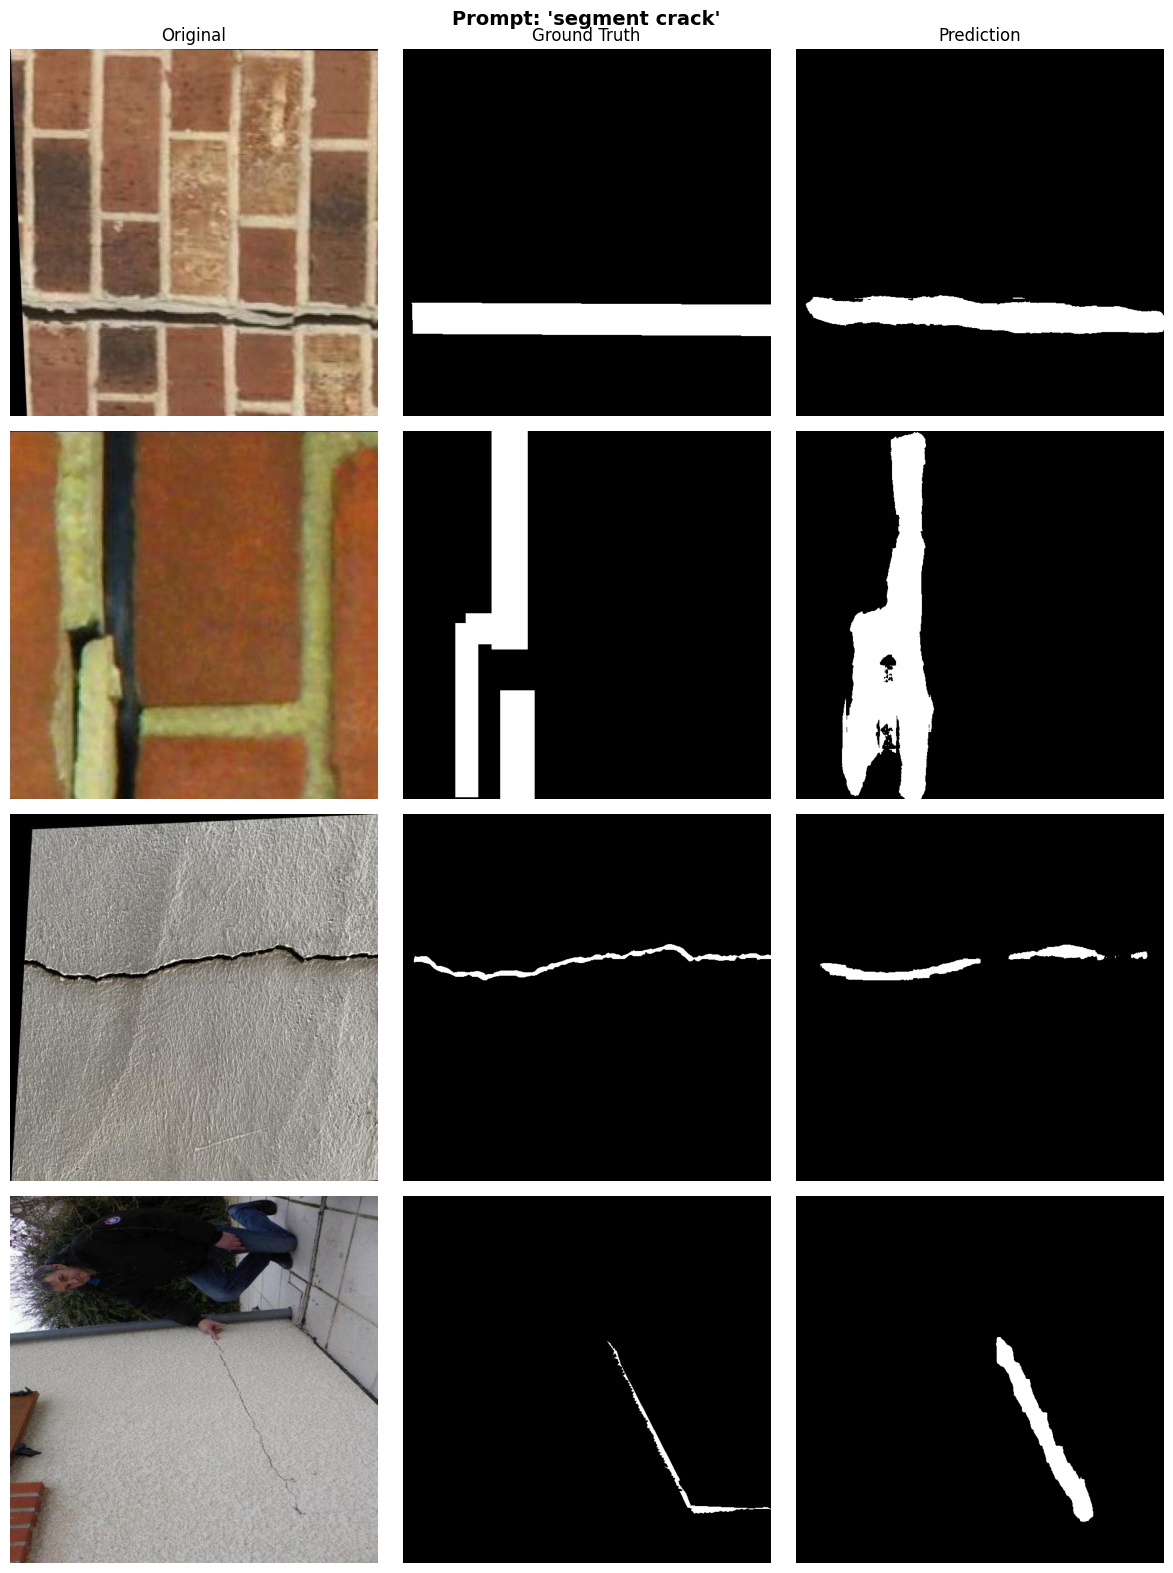

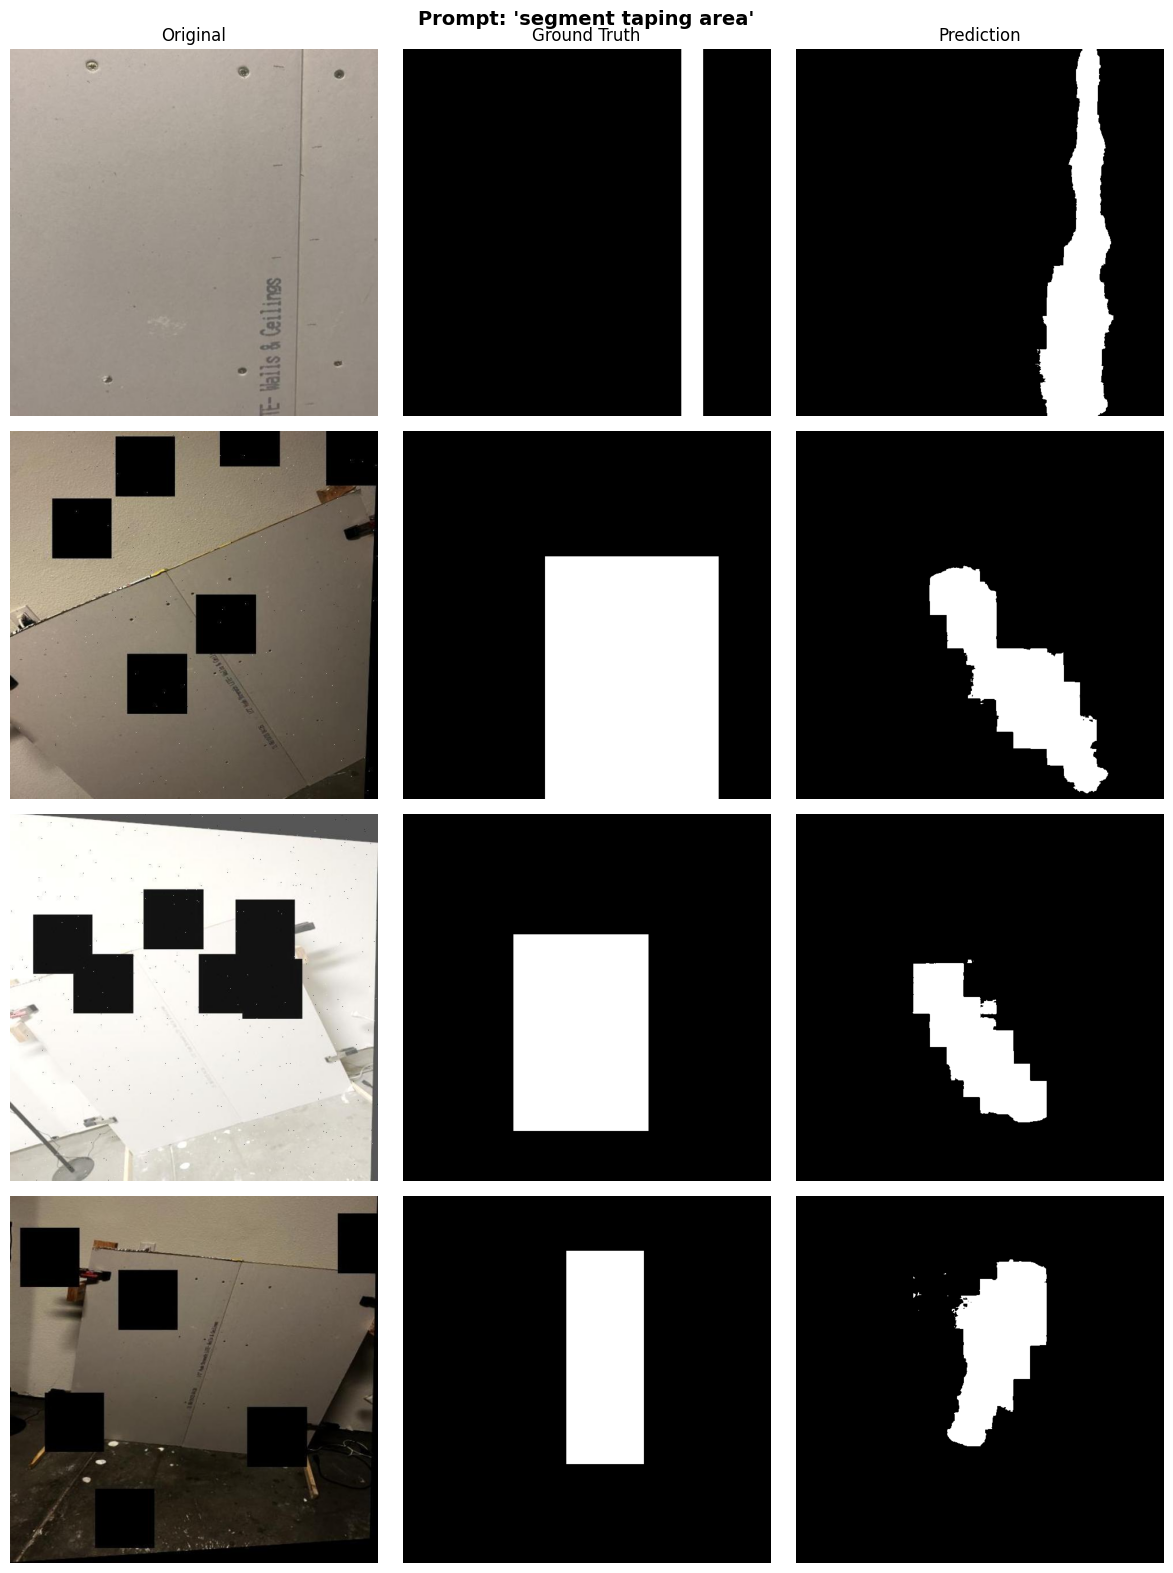

In [50]:
def save_visual_examples(image_dir, mask_dir, pred_dir, prompt, coco_ann_file, output_path, n=4, skip=0):
    coco = COCO(coco_ann_file)
    id_to_file = {str(img_id): info['file_name'] for img_id, info in coco.imgs.items()}
    prompt_slug = prompt.replace(" ", "_")
    
    all_mask_files = [f for f in os.listdir(mask_dir) 
                  if os.path.exists(os.path.join(pred_dir, f"{f.split('__')[0]}__{prompt_slug}.png"))]
    random.shuffle(all_mask_files)
    mask_files = all_mask_files[skip:skip+n]

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    fig.suptitle(f"Prompt: '{prompt}'", fontsize=14, fontweight='bold')
    for ax, col in zip(axes[0], ["Original", "Ground Truth", "Prediction"]):
        ax.set_title(col, fontsize=12)
    for i, mask_file in enumerate(mask_files):
        coco_id = mask_file.split("__")[0]
        orig_filename = id_to_file[coco_id]
        orig = Image.open(os.path.join(image_dir, orig_filename)).convert("RGB")
        gt = Image.open(os.path.join(mask_dir, mask_file)).convert("L")
        pred = Image.open(os.path.join(pred_dir, f"{coco_id}__{prompt_slug}.png")).convert("L")
        axes[i][0].imshow(orig)
        axes[i][1].imshow(gt, cmap="gray")
        axes[i][2].imshow(pred, cmap="gray")
        for j in range(3):
            axes[i][j].axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved {output_path}")

save_visual_examples(
    "/kaggle/input/datasets/krishnasaigollamudi/cracks/test",
    "/kaggle/working/crack_test_masks",
    "/kaggle/working/predictions",
    "segment crack",
    "/kaggle/input/datasets/krishnasaigollamudi/cracks/test/_annotations.coco.json",
    "/kaggle/working/visuals_crack.png"
)

save_visual_examples(
    "/kaggle/input/datasets/krishnasaigollamudi/drywall/valid",
    "/kaggle/working/drywall_valid_masks",
    "/kaggle/working/predictions",
    "segment taping area",
    "/kaggle/input/datasets/krishnasaigollamudi/drywall/valid/_annotations.coco.json",
    "/kaggle/working/visuals_drywall.png"
)